In [1]:
from pathlib import Path
import pandas as pd
import json

project_root = processed_dir.parents[1]

raw_path = project_root / "data" / "PS_20174392719_1491204439457_log.csv"
clean_path = processed_dir / "paysim_clean.csv"

print("Project root:", project_root)
print("Raw path exists:", raw_path.exists(), raw_path)
print("Clean path exists:", clean_path.exists(), clean_path)

df_raw = pd.read_csv(raw_path)
df_clean = pd.read_csv(clean_path)

print("Raw shape:", df_raw.shape)
print("Clean shape:", df_clean.shape)

print("\nRaw columns:")
print(df_raw.columns.tolist())

print("\nClean columns:")
print(df_clean.columns.tolist())

NameError: name 'processed_dir' is not defined

In [16]:
print(df_raw["type"].head())
print(df_clean["type"].head())

print(df_raw["type"].dtype)
print(df_clean["type"].dtype)

0     PAYMENT
1     PAYMENT
2    TRANSFER
3    CASH_OUT
4     PAYMENT
Name: type, dtype: object
0    3
1    3
2    4
3    1
4    3
Name: type, dtype: int64
object
int64


In [18]:
mapping_path = processed_dir / "paysim_type_mapping.json"

print(mapping_path.exists())
print(mapping_path.read_text(encoding="utf-8"))

True
{
    "CASH_IN": 


In [19]:
from sklearn.preprocessing import LabelEncoder
import json

le = LabelEncoder()
le.fit(df_raw["type"])

type_mapping = {
    str(label): int(code)
    for label, code in zip(le.classes_, le.transform(le.classes_))
}

print(type_mapping)

with open(processed_dir / "paysim_type_mapping.json", "w", encoding="utf-8") as f:
    json.dump(type_mapping, f, indent=4)

{'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4}


In [20]:
with open(processed_dir / "paysim_type_mapping.json", "r", encoding="utf-8") as f:
    type_mapping = json.load(f)

print(type_mapping)

{'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4}


In [22]:
# Missing values
print("Missing values in raw data:")
print(df_raw.isnull().sum())

print("\nMissing values in cleaned data:")
print(df_clean.isnull().sum())

Missing values in raw data:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Missing values in cleaned data:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
sample_id         0
dtype: int64


In [23]:
print("Duplicate rows in raw data:", df_raw.duplicated().sum())
print("Duplicate rows in cleaned data:", df_clean.duplicated().sum())

Duplicate rows in raw data: 0
Duplicate rows in cleaned data: 0


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Select numerical/model-related columns
corr_cols = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud"
]

corr_matrix = df_clean[corr_cols].corr(method="spearman")

print(corr_matrix["isFraud"].sort_values(ascending=False))

isFraud           1.000000
oldbalanceOrg     0.039430
amount            0.036060
type              0.023058
step              0.020819
newbalanceDest   -0.005182
oldbalanceDest   -0.017141
newbalanceOrig   -0.028031
Name: isFraud, dtype: float64


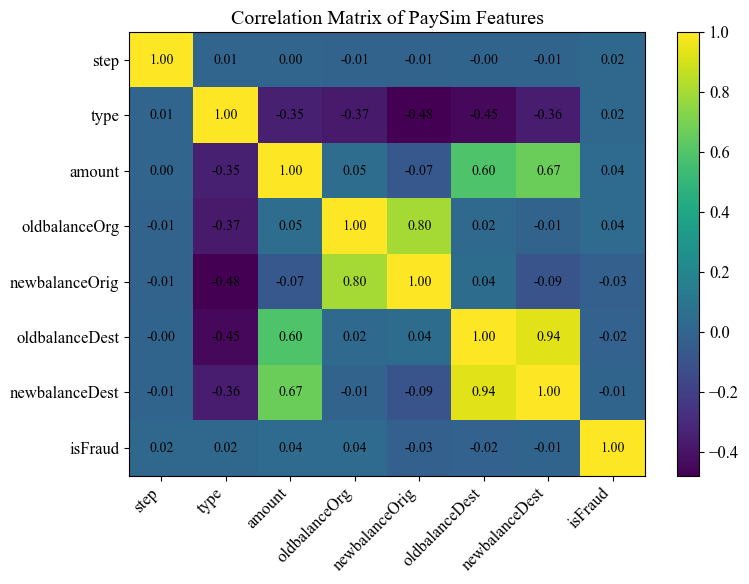

In [27]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=10)

ax.set_title("Correlation Matrix of PaySim Features")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig("paysim_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Fraud distribution by transaction type
type_fraud_summary = (
    df_raw
    .groupby("type")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

type_fraud_summary["fraud_rate_percent"] = (
    type_fraud_summary["fraud_rate"] * 100
).round(4)

type_fraud_summary = type_fraud_summary.sort_values(
    "fraud_rate_percent",
    ascending=False
)

print(type_fraud_summary)

       type  total_transactions  fraud_cases  fraud_rate  fraud_rate_percent
4  TRANSFER              532909         4097    0.007688              0.7688
1  CASH_OUT             2237500         4116    0.001840              0.1840
0   CASH_IN             1399284            0    0.000000              0.0000
2     DEBIT               41432            0    0.000000              0.0000
3   PAYMENT             2151495            0    0.000000              0.0000


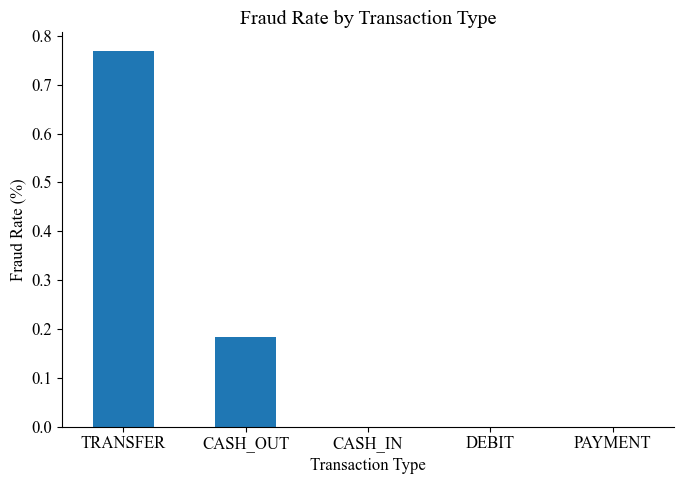

In [30]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

ax = type_fraud_summary.plot(
    x="type",
    y="fraud_rate_percent",
    kind="bar",
    figsize=(7, 5),
    legend=False
)

ax.set_title("Fraud Rate by Transaction Type")
ax.set_xlabel("Transaction Type")
ax.set_ylabel("Fraud Rate (%)")
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("paysim_fraud_rate_by_transaction_type.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

train = pd.read_csv(processed_dir / "paysim_train.csv")

print(train.shape)
train.head()

(4453834, 12)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,sample_id
0,226,1,30075.63,C461125461,74012.0,43936.37,C1111571328,0.0,30075.63,0,0,2834595
1,256,3,1235.68,C411279289,0.0,0.00,M1062559037,0.0,0.00,0,0,3429831
2,257,3,3382.27,C948860368,0.0,0.00,M1642901015,0.0,0.00,0,0,3443863
3,209,3,4181.40,C1727741970,33636.0,29454.60,M1537191546,0.0,0.00,0,0,2636077
4,161,0,114104.26,C380725160,2775869.4,2889973.66,C374325105,918761.6,804657.34,0,0,1743962


## isFlaggedFraud investigation

PaySim contains a rule-based flag (`isFlaggedFraud`) that fires when a TRANSFER
exceeds 200,000 units. Before training we check whether this flag captures most
fraud (a potential shortcut) or only a small fraction of it (a legitimate weak signal).

In [32]:
# How many transactions were flagged?
flagged = train[train["isFlaggedFraud"] == 1]

print("Flagged transactions:", len(flagged))
print("Fraud status among flagged:")
print(flagged["isFraud"].value_counts())

Flagged transactions: 14
Fraud status among flagged:
isFraud
1    14
Name: count, dtype: int64


In [33]:
total_flagged = (train["isFlaggedFraud"] == 1).sum()
flagged_and_fraud = ((train["isFlaggedFraud"] == 1) & (train["isFraud"] == 1)).sum()
total_fraud = (train["isFraud"] == 1).sum()

precision_flag = flagged_and_fraud / total_flagged * 100
coverage_flag = flagged_and_fraud / total_fraud * 100

print("Total flagged:", total_flagged)
print("Flagged and fraud:", flagged_and_fraud)
print("Total fraud cases:", total_fraud)
print(f"Precision of isFlaggedFraud: {precision_flag:.2f}%")
print(f"Coverage of fraud cases: {coverage_flag:.4f}%")

Total flagged: 14
Flagged and fraud: 14
Total fraud cases: 5749
Precision of isFlaggedFraud: 100.00%
Coverage of fraud cases: 0.2435%


In [34]:
fraud_by_type = (
    train
    .groupby("type")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

fraud_by_type["fraud_rate_percent"] = (fraud_by_type["fraud_rate"] * 100).round(4)

print(fraud_by_type)

   type  total_transactions  fraud_cases  fraud_rate  fraud_rate_percent
0     0              979357            0    0.000000              0.0000
1     1             1566250         2883    0.001841              0.1841
2     2               29102            0    0.000000              0.0000
3     3             1505985            0    0.000000              0.0000
4     4              373140         2866    0.007681              0.7681


In [35]:
df_raw = pd.read_csv(raw_path)

le = LabelEncoder()
le.fit(df_raw["type"])

type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
inverse_type_mapping = {v: k for k, v in type_mapping.items()}

print("Type mapping:")
print(type_mapping)

print("Inverse mapping:")
print(inverse_type_mapping)

Type mapping:
{'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2), 'PAYMENT': np.int64(3), 'TRANSFER': np.int64(4)}
Inverse mapping:
{np.int64(0): 'CASH_IN', np.int64(1): 'CASH_OUT', np.int64(2): 'DEBIT', np.int64(3): 'PAYMENT', np.int64(4): 'TRANSFER'}


In [36]:
fraud_by_type["type_name"] = fraud_by_type["type"].map(inverse_type_mapping)

fraud_by_type = fraud_by_type[
    ["type", "type_name", "total_transactions", "fraud_cases", "fraud_rate_percent"]
]

print(fraud_by_type.to_string(index=False))

 type type_name  total_transactions  fraud_cases  fraud_rate_percent
    0   CASH_IN              979357            0              0.0000
    1  CASH_OUT             1566250         2883              0.1841
    2     DEBIT               29102            0              0.0000
    3   PAYMENT             1505985            0              0.0000
    4  TRANSFER              373140         2866              0.7681


The dataset was inspected for missing values and duplicate rows before preprocessing. No substantial missingness was observed, and the dataset was then prepared by encoding categorical variables and generating stratified train, validation, and test splits.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
processed_dir = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed")
print(processed_dir.exists())

True


In [5]:
df_paysim_clean = pd.read_csv(processed_dir / "paysim_clean.csv")
print(df_paysim_clean.shape)
df_paysim_clean.head()

(6362620, 12)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,sample_id
0,1,3,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0
1,1,3,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1
2,1,4,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,2
3,1,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,3
4,1,3,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,4


In [24]:
df_paysim_clean.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'sample_id']

In [4]:
import matplotlib.pyplot as plt

def plot_class_distribution(df):
    class_counts = df["isFraud"].value_counts().sort_index()

    plt.figure(figsize=(6, 4))
    class_counts.plot(kind="bar")
    plt.xticks([0, 1], ["Non-Fraud", "Fraud"], rotation=0)
    plt.ylabel("Number of transactions")
    plt.title("Class distribution of the PaySim dataset")
    plt.tight_layout()
    plt.show()

def plot_transaction_type_distribution(df):
    type_counts = df["type"].value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    type_counts.plot(kind="bar")
    plt.ylabel("Number of transactions")
    plt.title("Transaction type distribution in PaySim")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

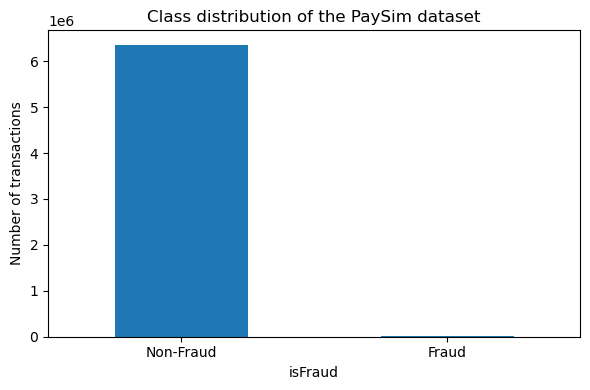

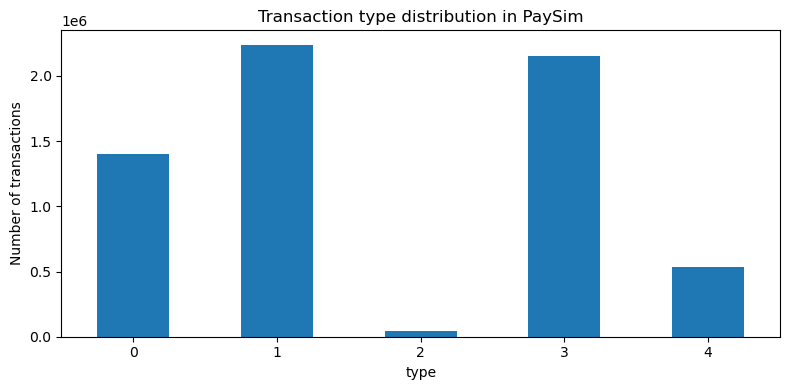

In [5]:
plot_class_distribution(df_paysim_clean)
plot_transaction_type_distribution(df_paysim_clean)

In [6]:
type_map_reverse = {
    0: "CASH_IN",
    1: "CASH_OUT",
    2: "DEBIT",
    3: "PAYMENT",
    4: "TRANSFER"
}

def plot_transaction_type_distribution_named(df):
    type_counts = df["type"].value_counts().sort_index()
    labels = [type_map_reverse[i] for i in type_counts.index]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, type_counts.values)
    plt.ylabel("Number of transactions")
    plt.title("Transaction type distribution in PaySim")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

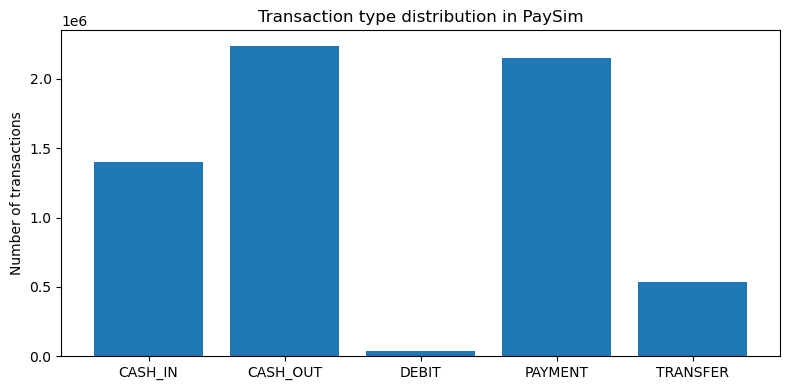

In [7]:
plot_transaction_type_distribution_named(df_paysim_clean)

In [8]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"

paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test = pd.read_csv(processed_dir / "paysim_test.csv")

paysim_full = pd.concat([paysim_train, paysim_val, paysim_test], ignore_index=True)

print("Train:", paysim_train.shape)
print("Validation:", paysim_val.shape)
print("Test:", paysim_test.shape)
print("Full:", paysim_full.shape)

Train: (4453834, 12)
Validation: (636262, 12)
Test: (1272524, 12)
Full: (6362620, 12)


In [9]:
print("Columns:")
print(paysim_full.columns.tolist())

print("\nData types:")
print(paysim_full.dtypes)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'sample_id']

Data types:
step                int64
type                int64
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
sample_id           int64
dtype: object


In [10]:
missing = paysim_full.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values:")
print(missing if len(missing) > 0 else "No missing values")

Missing values:
No missing values


In [11]:
target_counts = paysim_full["isFraud"].value_counts().sort_index()
target_percent = paysim_full["isFraud"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent.round(4)
})

target_summary

,count,percent
isFraud,,
0,6354407,99.8709
1,8213,0.1291


In [24]:
import pandas as pd

train = pd.read_csv(processed_dir / "paysim_train.csv")
val = pd.read_csv(processed_dir / "paysim_val.csv")
test = pd.read_csv(processed_dir / "paysim_test.csv")

summary = []

for split_name, df in [("Train", train), ("Validation", val), ("Test", test)]:
    non_fraud = (df["isFraud"] == 0).sum()
    fraud = (df["isFraud"] == 1).sum()
    total = len(df)
    fraud_percentage = fraud / total * 100

    summary.append({
        "Split": split_name,
        "Total observations": total,
        "Non-fraud": non_fraud,
        "Fraud": fraud,
        "Fraud percentage": round(fraud_percentage, 4)
    })

split_summary = pd.DataFrame(summary)
split_summary

,Split,Total observations,Non-fraud,Fraud,Fraud percentage
0,Train,4453834,4448085,5749,0.1291
1,Validation,636262,635441,821,0.1290
2,Test,1272524,1270881,1643,0.1291


In [25]:
print(split_summary.to_string(index=False))

     Split  Total observations  Non-fraud  Fraud  Fraud percentage
     Train             4453834    4448085   5749            0.1291
Validation              636262     635441    821            0.1290
      Test             1272524    1270881   1643            0.1291


In [37]:
print(df_clean["type"].head())
print(df_clean["type"].dtype)
print(df_clean["type"].unique())

0    3
1    3
2    4
3    1
4    3
Name: type, dtype: int64
int64
[3 4 1 2 0]


In [38]:
[col for col in df_clean.columns if "type" in col]

['type']

In [39]:
import os

project_root = processed_dir.parents[1]

for root, dirs, files in os.walk(project_root):
    for file in files:
        if file.endswith((".py", ".ipynb")):
            path = os.path.join(root, file)
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()
                if "OneHotEncoder" in text or "get_dummies" in text or "LabelEncoder" in text:
                    print(path)
                    if "OneHotEncoder" in text:
                        print("  contains OneHotEncoder")
                    if "get_dummies" in text:
                        print("  contains get_dummies")
                    if "LabelEncoder" in text:
                        print("  contains LabelEncoder")

C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\.venv\Lib\site-packages\pandas\__init__.py
  contains get_dummies
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\.venv\Lib\site-packages\pandas\core\arrays\categorical.py
  contains get_dummies
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\.venv\Lib\site-packages\pandas\core\arrays\string_arrow.py
  contains get_dummies
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\.venv\Lib\site-packages\pandas\core\arrays\arrow\array.py
  contains get_dummies
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\.venv\Lib\site-packages\pandas\core\reshape\api.py
  contains get_dummies
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\.venv\Lib\site-packages\pandas\core\reshape\encoding.py
  contains get_dummies
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\.venv\Lib\site-packages\pandas\core\strings\accessor.py
  contains get_dummies
C:\Users\A